# Statistique Avancee - RGPH 2014

**Projet SFE : Systeme Analytique Intelligent - RGPH 2014**

Ce notebook propose une analyse statistique avancee des micro-donnees du Recensement General de la Population et de l'Habitat du Maroc 2014. Il couvre l'inspection des donnees, les statistiques descriptives, les analyses demographiques, education, emploi, handicap, les tests statistiques, la correlation, la PCA et une segmentation regionale par K-Means.

Les scores de vulnerabilite produits ici sont des **proxies academiques** construits a partir des variables disponibles. Ils servent a l'analyse, a la soutenance et au dashboard, mais ne doivent pas etre presentes comme des indicateurs officiels du HCP.

## 1. Importation des bibliotheques

Cette section importe les bibliotheques necessaires et applique un style visuel sobre pour les graphiques. Le notebook est concu pour eviter les erreurs lorsque certaines colonnes sont absentes.

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, kruskal, f_oneway, shapiro
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

try:
    from IPython.display import display, Markdown
except ImportError:
    def display(obj):
        print(obj)
    def Markdown(text):
        return text

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

RANDOM_STATE = 42
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Environnement pret.")

Environnement pret.


## 2. Chargement des donnees et inspection automatique des colonnes

Le notebook charge `Individu.csv` et tente de charger `Menage.csv` si disponible. Ensuite, il inspecte les colonnes reelles et cree un dictionnaire `COLS` qui mappe les variables conceptuelles vers les noms effectivement presents dans les donnees.

In [2]:
INDIVIDU_PATH = Path("Individu.csv")
MENAGE_PATH = Path("Menage.csv")

def load_csv_if_exists(path: Path, required: bool = False) -> pd.DataFrame | None:
    if not path.exists():
        message = f"Fichier absent: {path}"
        if required:
            raise FileNotFoundError(message)
        print(message)
        return None
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f"{path.name} charge: {df.shape[0]:,} lignes x {df.shape[1]:,} colonnes")
        return df
    except Exception as exc:
        if required:
            raise
        print(f"Impossible de charger {path}: {exc}")
        return None

df_ind = load_csv_if_exists(INDIVIDU_PATH, required=True)
df_men = load_csv_if_exists(MENAGE_PATH, required=False)

print("\nColonnes detectees dans Individu.csv:")
display(pd.DataFrame({"colonne": df_ind.columns, "type": [str(t) for t in df_ind.dtypes]}))

display(df_ind.head())

Individu.csv charge: 99,962 lignes x 45 colonnes
Fichier absent: Menage.csv

Colonnes detectees dans Individu.csv:


,colonne,type
0,reg,int64
1,pro,int64
2,mil,int64
3,MEN_PRO,int64
4,NOR_MEN,int64
5,LIEN_CM,int64
6,natio,int64
7,sexe,int64
8,AGE1,float64
9,AGE5,int64


,reg,pro,mil,MEN_PRO,NOR_MEN,LIEN_CM,natio,sexe,AGE1,AGE5,E_MAT,ENF_VIV,ENF_DEC,ENF_VIV_12M,ENF_DEC_12M,HANDI_VIS,HANDI_AUD,HANDI_MOB,HANDI_MEM,HANDI_ENTR,HANDI_COM,SIT_HANDICAP,NIV_ET,NIV_ET_AGR,SEC_ENS,scol,ET_LIEU,ET_TRANS,LIR_ECR,LANG1,LANG_LOC1,LANG_LOC2,LANG2,LANG3,EG_DIP_GG_DET,FP_DIP_GG,TY_ACT,PROF_SGG,PROF_GG,STAT_PROF,ACT_SECTION,ACT_SECTEUR,TRAV_LIEU,TRAV_TRANS,pds
0,2,21,2,1,1,0,1,2,NaN,55,NaN,NaN,NaN,NaN,NaN,1,1,1,1,1,1,3,3,4,NaN,1.0,NaN,NaN,NaN,4.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.999995
1,2,21,2,1,2,4,1,1,NaN,25,NaN,NaN,NaN,NaN,NaN,4,1,1,1,1,1,1,3,2,NaN,2.0,1.0,NaN,1.0,1.0,2.0,NaN,3.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.999995
2,2,21,2,1,3,4,1,1,NaN,65,NaN,NaN,NaN,NaN,NaN,1,1,1,1,1,1,3,1,3,2.0,NaN,NaN,1.0,1.0,1.0,1.0,NaN,2.0,NaN,NaN,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.999995
3,2,21,2,1,4,4,1,1,NaN,25,NaN,NaN,NaN,NaN,NaN,1,1,2,1,1,1,3,5,0,NaN,NaN,2.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,28.0,9.0,1.0,12.0,2.0,4.0,3.0,9.999995
4,10,106,2,2,1,2,1,1,1.0,5,NaN,NaN,NaN,NaN,NaN,1,1,1,1,1,1,1,3,2,NaN,1.0,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.999995


In [3]:
# Adaptation automatique aux noms reels des colonnes.
# Chaque cle represente une variable conceptuelle; la valeur sera le nom reel trouve dans le CSV.

COLUMN_ALIASES = {
    "region": ["reg", "REG", "region", "region_id", "code_region"],
    "province": ["pro", "province", "code_province"],
    "milieu": ["mil", "MIL", "milieu"],
    "menage_id": ["MEN_PRO", "menage_id", "id_menage"],
    "ordre_menage": ["NOR_MEN", "ordre_menage"],
    "lien_cm": ["LIEN_CM", "lien_cm"],
    "sexe": ["sexe", "SEXE", "sex"],
    "age5": ["AGE5", "age5", "age"],
    "age1": ["AGE1", "age1"],
    "alphab": ["LIR_ECR", "lir_ecr", "alphabetisme"],
    "educ": ["NIV_ET_AGR", "niv_et_agr", "niveau_education"],
    "educ_detail": ["NIV_ET", "niv_et"],
    "scolarise": ["scol", "SCOL"],
    "diplome": ["EG_DIP_GG_DET", "EG_DIP_GG", "diplome"],
    "formation_pro": ["FP_DIP_GG", "formation_pro"],
    "ty_act": ["TY_ACT", "ty_act"],
    "stat_prof": ["STAT_PROF", "stat_prof"],
    "secteur": ["ACT_SECTEUR", "act_secteur"],
    "sit_handicap": ["SIT_HANDICAP", "sit_handicap"],
    "handi_vis": ["HANDI_VIS"],
    "handi_aud": ["HANDI_AUD"],
    "handi_mob": ["HANDI_MOB"],
    "handi_mem": ["HANDI_MEM"],
    "handi_entr": ["HANDI_ENTR"],
    "handi_com": ["HANDI_COM"],
    "enf_viv": ["ENF_VIV"],
    "enf_dec": ["ENF_DEC"],
}

def resolve_columns(df: pd.DataFrame, aliases: dict[str, list[str]]) -> dict[str, str | None]:
    lower_lookup = {c.lower(): c for c in df.columns}
    resolved = {}
    for key, candidates in aliases.items():
        found = None
        for cand in candidates:
            if cand in df.columns:
                found = cand
                break
            if cand.lower() in lower_lookup:
                found = lower_lookup[cand.lower()]
                break
        resolved[key] = found
    return resolved

COLS = resolve_columns(df_ind, COLUMN_ALIASES)
cols_table = pd.DataFrame(
    [{"variable": k, "colonne_reelle": v, "disponible": v is not None} for k, v in COLS.items()]
)
display(cols_table)

missing_concepts = cols_table.loc[~cols_table["disponible"], "variable"].tolist()
print("Variables conceptuelles absentes:", missing_concepts if missing_concepts else "Aucune variable critique absente.")

,variable,colonne_reelle,disponible
0,region,reg,True
1,province,pro,True
2,milieu,mil,True
3,menage_id,MEN_PRO,True
4,ordre_menage,NOR_MEN,True
5,lien_cm,LIEN_CM,True
6,sexe,sexe,True
7,age5,AGE5,True
8,age1,AGE1,True
9,alphab,LIR_ECR,True


Variables conceptuelles absentes: Aucune variable critique absente.


## 3. Nettoyage statistique de base

On quantifie les valeurs manquantes, les doublons, les types de colonnes et les valeurs incoherentes sur les variables RGPH principales. Les NaN conditionnels ne sont pas supprimes automatiquement, car ils peuvent signifier "non concerne" selon l'age, le sexe ou le statut d'activite.

In [4]:
def existing(keys: list[str]) -> list[str]:
    return [COLS[k] for k in keys if COLS.get(k) is not None]

missing_stats = (
    df_ind.isna().sum()
    .to_frame("nb_missing")
    .assign(pct_missing=lambda d: (d["nb_missing"] / len(df_ind) * 100).round(2))
    .sort_values("pct_missing", ascending=False)
)
display(missing_stats.head(30))

numeric_cols = df_ind.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in df_ind.columns if c not in numeric_cols]

print(f"Colonnes numeriques: {len(numeric_cols)}")
print(f"Colonnes categorielles/non numeriques: {len(categorical_cols)}")
print(f"Doublons exacts: {df_ind.duplicated().sum():,}")

,nb_missing,pct_missing
LANG3,90082,90.12
FP_DIP_GG,89855,89.89
LANG_LOC2,84857,84.89
AGE1,81105,81.14
E_MAT,79281,79.31
ENF_VIV_12M,78159,78.19
ENF_DEC_12M,78159,78.19
ENF_DEC,78159,78.19
ENF_VIV,78159,78.19
ET_TRANS,75139,75.17


Colonnes numeriques: 45
Colonnes categorielles/non numeriques: 0
Doublons exacts: 0


In [5]:
EXPECTED_RANGES = {
    "region": set(range(1, 13)),
    "milieu": {1, 2},
    "sexe": {1, 2},
    "alphab": {1, 2, 3},
    "ty_act": {0, 1, 2, 3, 4, 5},
    "sit_handicap": {1, 2, 3, 4},
}

incoherences = []
for key, allowed in EXPECTED_RANGES.items():
    col = COLS.get(key)
    if col is None:
        continue
    values = pd.to_numeric(df_ind[col], errors="coerce")
    invalid = values.dropna()[~values.dropna().isin(allowed)]
    incoherences.append({
        "variable": key,
        "colonne": col,
        "nb_invalides": int(invalid.shape[0]),
        "exemples": sorted(invalid.unique().tolist())[:10],
    })

age_col = COLS.get("age5")
if age_col:
    age = pd.to_numeric(df_ind[age_col], errors="coerce")
    invalid_age = age.dropna()[(age.dropna() < 0) | (age.dropna() > 120)]
    incoherences.append({
        "variable": "age5",
        "colonne": age_col,
        "nb_invalides": int(invalid_age.shape[0]),
        "exemples": sorted(invalid_age.unique().tolist())[:10],
    })

display(pd.DataFrame(incoherences))

,variable,colonne,nb_invalides,exemples
0,region,reg,0,[]
1,milieu,mil,0,[]
2,sexe,sexe,0,[]
3,alphab,LIR_ECR,0,[]
4,ty_act,TY_ACT,0,[]
5,sit_handicap,SIT_HANDICAP,0,[]
6,age5,AGE5,0,[]


## 4. Statistiques descriptives avancees

Le tableau `desc_stats_advanced` resume les variables numeriques avec moyenne, mediane, ecart-type, variance, quartiles, skewness et kurtosis.

In [6]:
def advanced_describe(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for col in columns:
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if s.empty:
            continue
        rows.append({
            "variable": col,
            "count": int(s.count()),
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "variance": s.var(),
            "min": s.min(),
            "q1": s.quantile(0.25),
            "q3": s.quantile(0.75),
            "max": s.max(),
            "skewness": s.skew(),
            "kurtosis": s.kurtosis(),
        })
    return pd.DataFrame(rows).round(4)

desc_stats_advanced = advanced_describe(df_ind, numeric_cols)
display(desc_stats_advanced)

,variable,count,mean,median,std,variance,min,q1,q3,max,skewness,kurtosis
0,reg,99962,6.4691,6.0,3.4462,1.187600e+01,1.0,3.00,9.0,12.0,0.0158,-1.2131
1,pro,99962,68.7030,67.0,34.5288,1.192241e+03,11.0,37.00,97.0,127.0,0.0154,-1.2041
2,mil,99962,1.4012,1.0,0.4902,2.402000e-01,1.0,1.00,2.0,2.0,0.4030,-1.8376
3,MEN_PRO,99962,9995.5821,9965.0,5776.3128,3.336579e+07,1.0,4979.25,14995.0,20000.0,0.0060,-1.2021
4,NOR_MEN,99962,3.6677,3.0,2.2113,4.889800e+00,1.0,2.00,5.0,9.0,0.5703,-0.6468
5,LIEN_CM,99962,3.1710,2.0,2.9161,8.503700e+00,0.0,1.00,4.0,9.0,1.0478,-0.0356
6,natio,99962,1.0687,1.0,0.3778,1.427000e-01,1.0,1.00,1.0,4.0,6.2008,40.1390
7,sexe,99962,1.4983,1.0,0.5000,2.500000e-01,1.0,1.00,2.0,2.0,0.0068,-2.0000
8,AGE1,18857,0.9924,1.0,0.8167,6.670000e-01,0.0,0.00,2.0,2.0,0.0140,-1.5006
9,AGE5,99962,37.4810,35.0,23.1379,5.353641e+02,0.0,15.00,60.0,75.0,0.0030,-1.2158


## 5. Construction des indicateurs socio-economiques

Cette cellule cree les indicateurs utilises par les analyses suivantes. Les formules reprennent la logique du projet : education, emploi, handicap, age vulnerable et score proxy de vulnerabilite.

In [7]:
df = df_ind.copy()

def to_num(col: str | None, default=np.nan) -> pd.Series:
    if col is None or col not in df.columns:
        return pd.Series(default, index=df.index)
    return pd.to_numeric(df[col], errors="coerce")

reg = to_num(COLS.get("region"))
mil = to_num(COLS.get("milieu"))
sexe = to_num(COLS.get("sexe"))
age5 = to_num(COLS.get("age5"))
educ = to_num(COLS.get("educ"))
alphab = to_num(COLS.get("alphab"))
ty_act = to_num(COLS.get("ty_act"))
sit_handicap = to_num(COLS.get("sit_handicap"))

if "a_diplome_eg" not in df.columns:
    diplome_col = COLS.get("diplome")
    df["a_diplome_eg"] = to_num(diplome_col).notna().astype(int) if diplome_col else 0

if "a_formation_pro" not in df.columns:
    fp_col = COLS.get("formation_pro")
    df["a_formation_pro"] = to_num(fp_col).notna().astype(int) if fp_col else 0

if "scolarise_actuel" not in df.columns:
    scol_col = COLS.get("scolarise")
    df["scolarise_actuel"] = (to_num(scol_col) == 1).astype(int) if scol_col else 0

if "indice_scolarisation" not in df.columns:
    score_edu = pd.Series(0.0, index=df.index)
    if COLS.get("educ"):
        score_edu += educ.clip(0, 5).fillna(0) / 5 * 0.5
    if COLS.get("alphab"):
        score_edu += alphab.map({1: 1.0, 2: 0.5, 3: 0.0}).fillna(0.5) * 0.3
    score_edu += df["a_diplome_eg"].fillna(0) * 0.2
    df["indice_scolarisation"] = score_edu.clip(0, 1)

if "est_occupe" not in df.columns:
    df["est_occupe"] = (ty_act == 0).astype(int)

if "est_chomeur" not in df.columns:
    df["est_chomeur"] = ty_act.isin([1, 2]).astype(int)

handi_cols = [c for c in existing(["handi_vis", "handi_aud", "handi_mob", "handi_mem", "handi_com"]) if c in df.columns]
if "a_handicap" not in df.columns:
    if handi_cols:
        df["a_handicap"] = (df[handi_cols].apply(pd.to_numeric, errors="coerce").max(axis=1) > 1).astype(int)
    elif COLS.get("sit_handicap"):
        df["a_handicap"] = sit_handicap.gt(1).fillna(False).astype(int)
    else:
        df["a_handicap"] = 0

score = pd.Series(0.0, index=df.index)
score += (mil == 2).astype(float) * 1.5
score += ((5 - educ.clip(0, 5)) / 5).fillna(0.5) * 2.0
score += alphab.map({1: 0.0, 2: 0.5, 3: 1.0}).fillna(0.5) * 1.5
adulte = age5 >= 15
score += (adulte & ty_act.isin([3, 5])).astype(float) * 1.5
score += (adulte & ty_act.isin([1, 2])).astype(float) * 1.0
score += sit_handicap.map({1: 0.0, 2: 0.5, 3: 1.0, 4: 2.0}).fillna(0.0)
score += ((age5 < 5) | (age5 >= 65)).astype(float) * 0.5
score += (1 - df["a_diplome_eg"]).fillna(0) * 0.5

df["score_vulnerabilite_proxy"] = score
df["classe_vulnerabilite"] = pd.qcut(
    score.rank(method="first"), q=3, labels=[0, 1, 2]
).astype(int)

display(df[["indice_scolarisation", "est_occupe", "est_chomeur", "a_handicap", "score_vulnerabilite_proxy", "classe_vulnerabilite"]].head())

,indice_scolarisation,est_occupe,est_chomeur,a_handicap,score_vulnerabilite_proxy,classe_vulnerabilite
0,0.55,0,1,0,5.15,2
1,0.50,0,0,1,3.20,0
2,0.60,0,0,0,5.80,2
3,0.15,1,0,1,5.75,2
4,0.35,0,0,0,3.95,1


**Note methodologique.** Le score `score_vulnerabilite_proxy` est un score academique. Il combine le milieu rural, la faible education, l'analphabetisme, le chomage ou l'inactivite, le handicap et l'age vulnerable. Il ne remplace pas un revenu observe, un indice officiel de pauvrete ou une mesure institutionnelle du HCP.

## 6. Analyse demographique

On analyse ici la repartition par region, milieu, sexe et age. Les libelles numeriques du RGPH sont conserves pour rester proches des donnees sources.

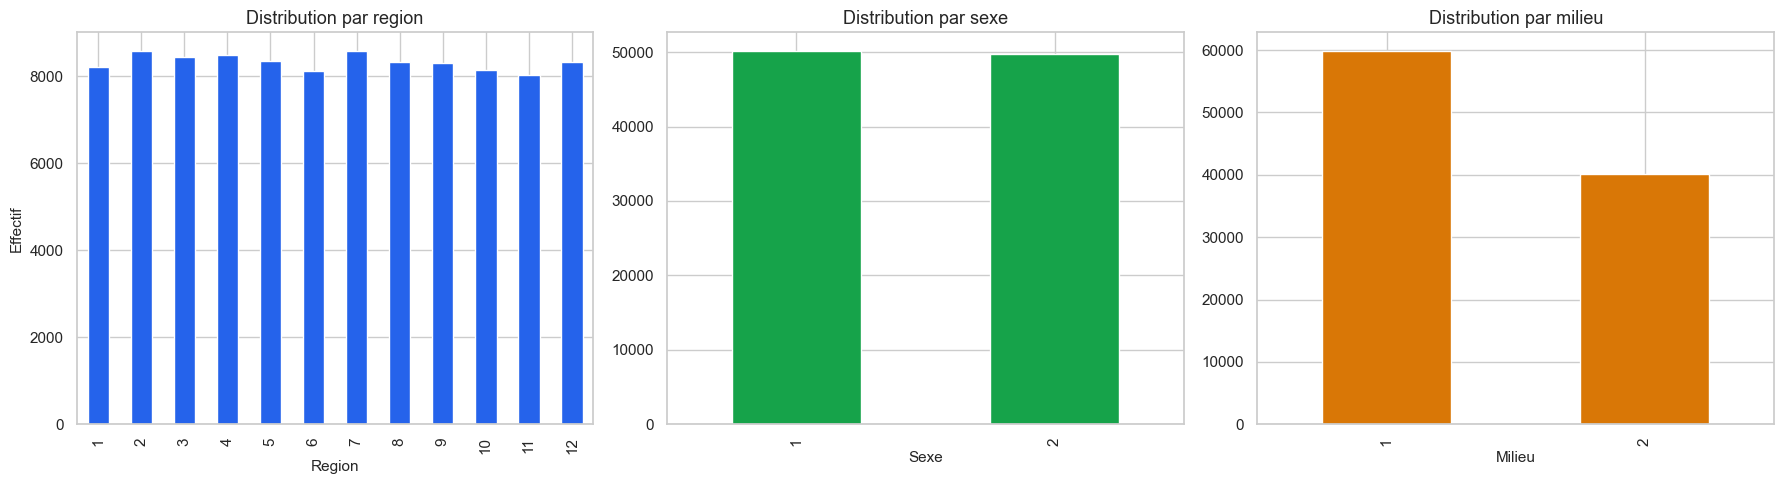

In [8]:
region_col = COLS.get("region")
milieu_col = COLS.get("milieu")
sexe_col = COLS.get("sexe")
age_col = COLS.get("age5")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if region_col:
    df[region_col].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#2563EB")
    axes[0].set_title("Distribution par region")
    axes[0].set_xlabel("Region")
    axes[0].set_ylabel("Effectif")

if sexe_col:
    df[sexe_col].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#16A34A")
    axes[1].set_title("Distribution par sexe")
    axes[1].set_xlabel("Sexe")

if milieu_col:
    df[milieu_col].value_counts().sort_index().plot(kind="bar", ax=axes[2], color="#D97706")
    axes[2].set_title("Distribution par milieu")
    axes[2].set_xlabel("Milieu")

plt.tight_layout()
plt.show()

,reg,population,age_moyen,pct_mineurs,pct_seniors,ratio_dependance
0,1,8217,37.491,18.802,24.960,0.438
1,2,8582,37.569,18.620,25.216,0.438
2,3,8438,37.573,18.926,25.219,0.442
3,4,8499,37.508,18.696,25.191,0.439
4,5,8363,36.951,19.347,24.465,0.438
5,6,8116,37.395,19.024,25.025,0.440
6,7,8579,37.494,19.221,25.446,0.447
7,8,8331,37.530,18.881,25.159,0.440
8,9,8317,37.717,18.793,25.358,0.442
9,10,8149,37.305,19.021,24.788,0.438


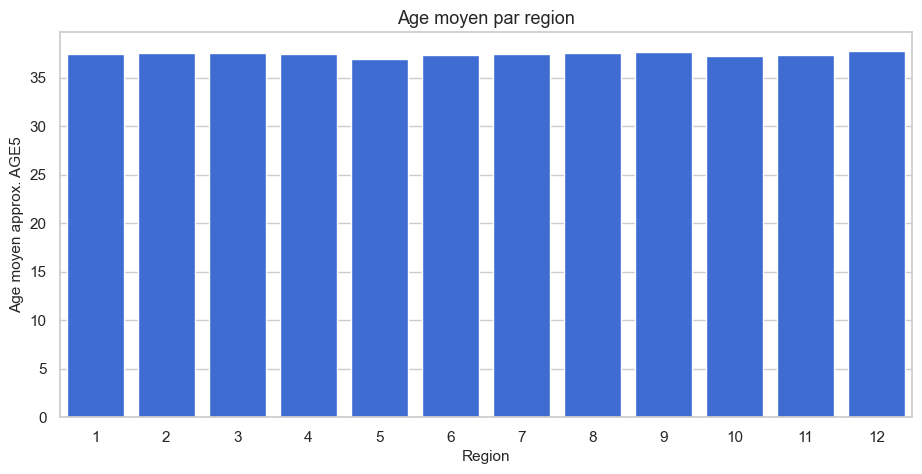

In [9]:
def pct(condition: pd.Series) -> float:
    return float(condition.mean() * 100)

group_cols = [c for c in [region_col] if c]
if group_cols and age_col:
    demo_region = df.groupby(region_col).agg(
        population=(age_col, "count"),
        age_moyen=(age_col, "mean"),
        pct_mineurs=(age_col, lambda s: pct(pd.to_numeric(s, errors="coerce") < 15)),
        pct_seniors=(age_col, lambda s: pct(pd.to_numeric(s, errors="coerce") >= 60)),
    ).reset_index()
    demo_region["ratio_dependance"] = ((demo_region["pct_mineurs"] + demo_region["pct_seniors"]) / 100).round(4)
    display(demo_region.round(3))

    sns.barplot(data=demo_region, x=region_col, y="age_moyen", color="#2563EB")
    plt.title("Age moyen par region")
    plt.xlabel("Region")
    plt.ylabel("Age moyen approx. AGE5")
    plt.show()
else:
    print("Colonnes region/age absentes: analyse demographique regionale ignoree.")

## 7. Analyse education

L'analyse porte sur le niveau d'education agrege, l'alphabetisme et l'indice de scolarisation construit.

,reg,mil,NIV_ET_AGR,LIR_ECR,indice_scolarisation
0,2,2,4,NaN,0.55
1,2,2,2,1.0,0.50
2,2,2,3,1.0,0.60
3,2,2,0,2.0,0.15
4,10,2,2,NaN,0.35


,reg,taux_alphabetisme,niveau_education_moyen,indice_scolarisation_moyen
0,1,44.347,2.506,0.521
1,2,44.116,2.464,0.517
2,3,44.572,2.513,0.524
3,4,44.558,2.493,0.518
4,5,43.800,2.478,0.520
5,6,42.952,2.489,0.516
6,7,43.385,2.485,0.517
7,8,43.764,2.480,0.518
8,9,43.117,2.512,0.520
9,10,43.919,2.514,0.521


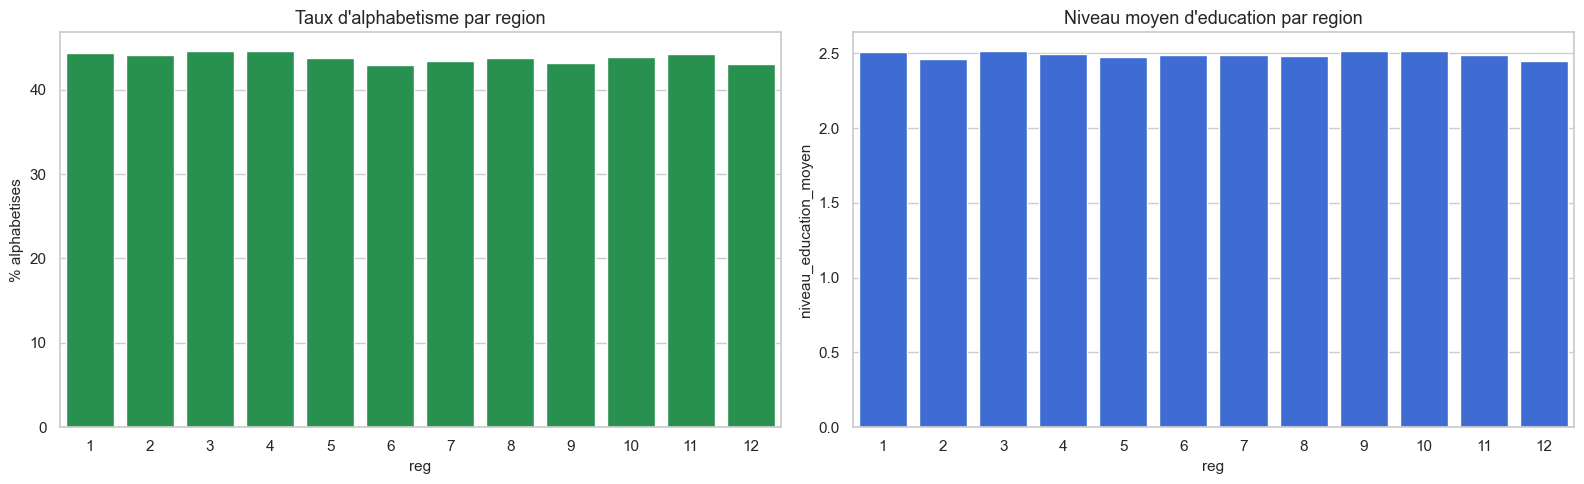

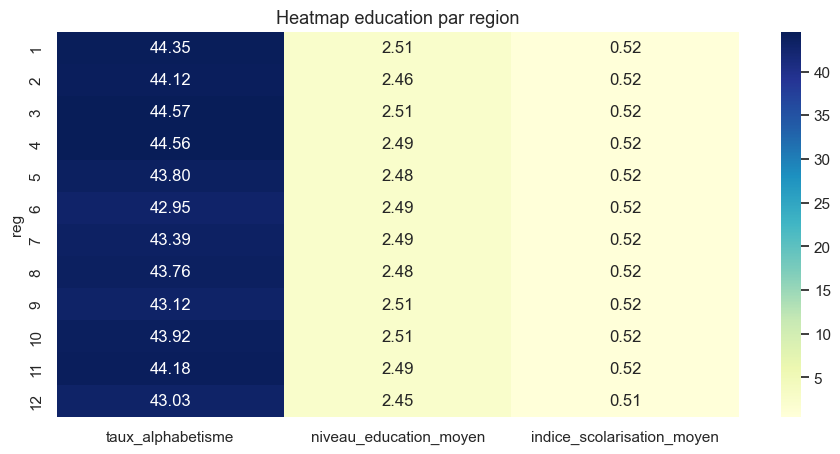

,indice_scolarisation
mil,
1,0.5184
2,0.5185


In [10]:
education_cols = [c for c in [region_col, milieu_col, COLS.get("educ"), COLS.get("alphab"), "indice_scolarisation"] if c]
display(df[education_cols].head())

if region_col and COLS.get("alphab") and COLS.get("educ"):
    edu_region = df.groupby(region_col).agg(
        taux_alphabetisme=(COLS["alphab"], lambda s: (pd.to_numeric(s, errors="coerce") == 1).mean() * 100),
        niveau_education_moyen=(COLS["educ"], "mean"),
        indice_scolarisation_moyen=("indice_scolarisation", "mean"),
    ).reset_index()
    display(edu_region.round(3))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.barplot(data=edu_region, x=region_col, y="taux_alphabetisme", ax=axes[0], color="#16A34A")
    axes[0].set_title("Taux d'alphabetisme par region")
    axes[0].set_ylabel("% alphabetises")

    sns.barplot(data=edu_region, x=region_col, y="niveau_education_moyen", ax=axes[1], color="#2563EB")
    axes[1].set_title("Niveau moyen d'education par region")
    plt.tight_layout()
    plt.show()

    heat = edu_region.set_index(region_col)[["taux_alphabetisme", "niveau_education_moyen", "indice_scolarisation_moyen"]]
    sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title("Heatmap education par region")
    plt.show()
else:
    print("Colonnes education/alphabetisme insuffisantes.")

if milieu_col:
    display(df.groupby(milieu_col)[["indice_scolarisation"]].mean().round(4))

## 8. Analyse emploi

On calcule les taux d'emploi et de chomage par region, par milieu et par sexe lorsque les colonnes sont disponibles.

,reg,taux_emploi,taux_chomage
0,1,27.492,8.592
1,2,27.872,8.122
2,3,29.746,8.011
3,4,28.003,8.095
4,5,27.956,8.263
5,6,28.499,7.935
6,7,27.171,8.264
7,8,28.472,8.330
8,9,28.231,7.503
9,10,28.961,7.792


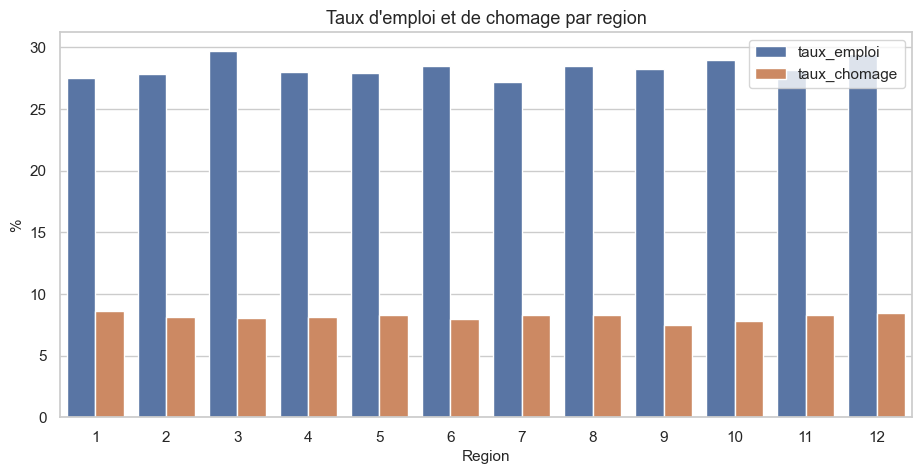

,est_occupe,est_chomeur
mil,,
1,28.32,8.08
2,28.35,8.23


,est_occupe,est_chomeur
sexe,,
1,28.42,8.13
2,28.24,8.15


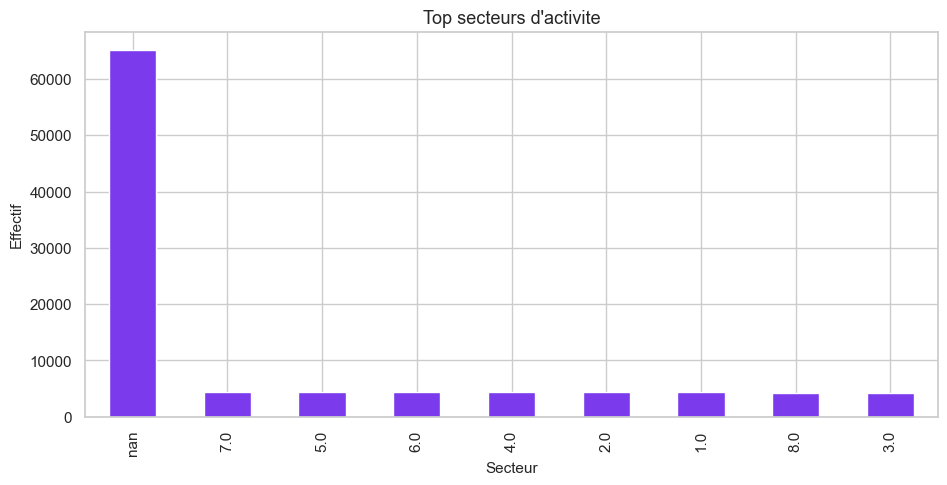

In [11]:
if region_col:
    emploi_region = df.groupby(region_col).agg(
        taux_emploi=("est_occupe", lambda s: s.mean() * 100),
        taux_chomage=("est_chomeur", lambda s: s.mean() * 100),
    ).reset_index()
    display(emploi_region.round(3))

    emploi_region_melt = emploi_region.melt(id_vars=region_col, var_name="indicateur", value_name="pourcentage")
    sns.barplot(data=emploi_region_melt, x=region_col, y="pourcentage", hue="indicateur")
    plt.title("Taux d'emploi et de chomage par region")
    plt.xlabel("Region")
    plt.ylabel("%")
    plt.legend(title="")
    plt.show()

if milieu_col:
    display(df.groupby(milieu_col)[["est_occupe", "est_chomeur"]].mean().mul(100).round(2))

if sexe_col:
    display(df.groupby(sexe_col)[["est_occupe", "est_chomeur"]].mean().mul(100).round(2))

secteur_col = COLS.get("secteur")
if secteur_col:
    secteur_counts = df[secteur_col].value_counts(dropna=False).head(15)
    secteur_counts.plot(kind="bar", color="#7C3AED")
    plt.title("Top secteurs d'activite")
    plt.xlabel("Secteur")
    plt.ylabel("Effectif")
    plt.show()

## 9. Analyse handicap

Cette section analyse la situation de handicap globale et par type de difficulte.

Colonnes handicap utilisees: ['SIT_HANDICAP', 'HANDI_VIS', 'HANDI_AUD', 'HANDI_MOB', 'HANDI_MEM', 'HANDI_COM']


,reg,taux_handicap,score_vulnerabilite_moyen
0,1,47.097,4.031
1,2,46.516,4.050
2,3,47.440,4.005
3,4,47.888,4.025
4,5,46.945,3.977
5,6,45.897,4.048
6,7,46.987,4.029
7,8,46.897,4.056
8,9,46.074,4.046
9,10,46.521,4.017


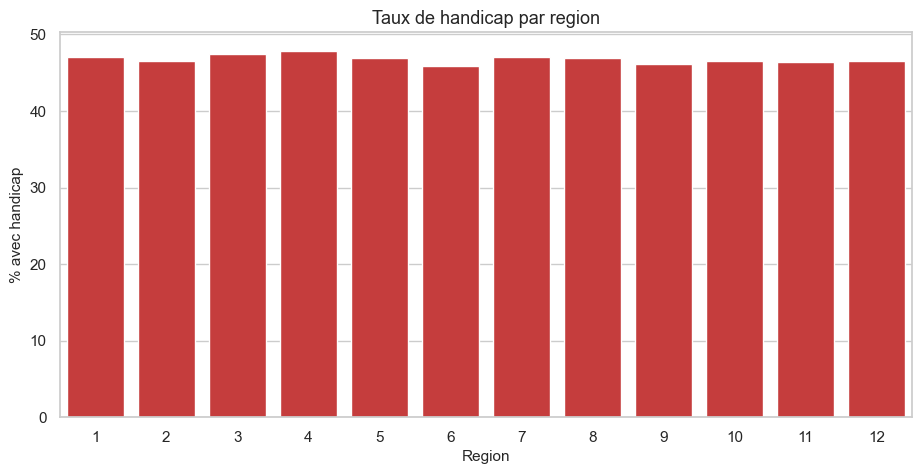

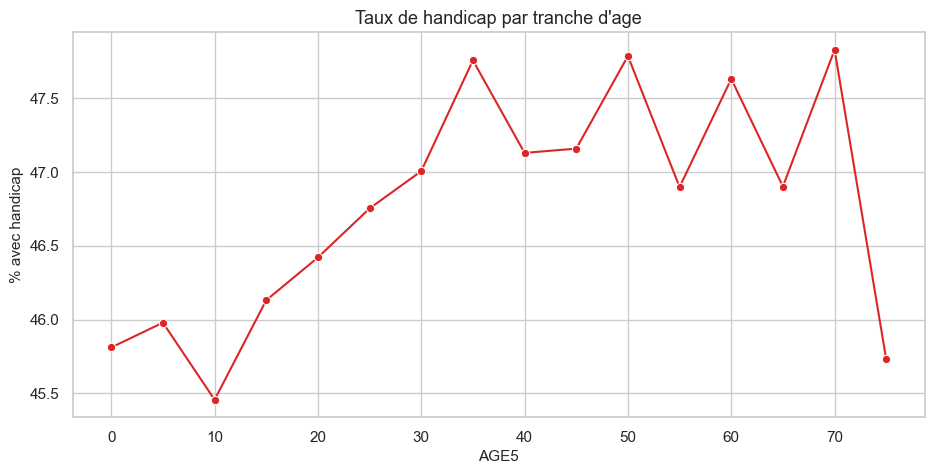

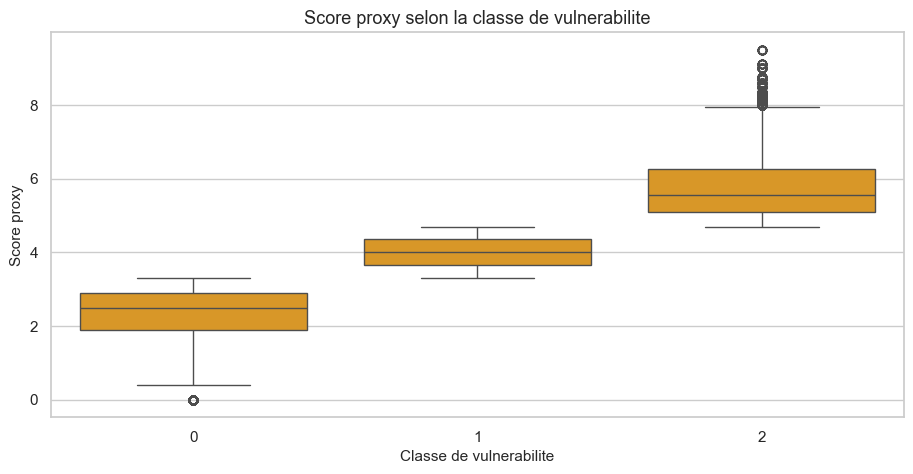

In [12]:
handicap_vars = [c for c in [COLS.get("sit_handicap")] + handi_cols if c]
print("Colonnes handicap utilisees:", handicap_vars)

if region_col:
    handicap_region = df.groupby(region_col).agg(
        taux_handicap=("a_handicap", lambda s: s.mean() * 100),
        score_vulnerabilite_moyen=("score_vulnerabilite_proxy", "mean"),
    ).reset_index()
    display(handicap_region.round(3))

    sns.barplot(data=handicap_region, x=region_col, y="taux_handicap", color="#DC2626")
    plt.title("Taux de handicap par region")
    plt.xlabel("Region")
    plt.ylabel("% avec handicap")
    plt.show()

if age_col:
    age_handicap = df.groupby(age_col)["a_handicap"].mean().mul(100).reset_index()
    sns.lineplot(data=age_handicap, x=age_col, y="a_handicap", marker="o", color="#DC2626")
    plt.title("Taux de handicap par tranche d'age")
    plt.xlabel("AGE5")
    plt.ylabel("% avec handicap")
    plt.show()

sns.boxplot(data=df, x="classe_vulnerabilite", y="score_vulnerabilite_proxy", color="#F59E0B")
plt.title("Score proxy selon la classe de vulnerabilite")
plt.xlabel("Classe de vulnerabilite")
plt.ylabel("Score proxy")
plt.show()

## 10. Tests statistiques avances

Chaque test est accompagne de son interpretation. Les tests utilisent un echantillon lorsque c'est necessaire pour garder le notebook rapide sur un grand fichier.

In [13]:
test_results = []

def interpret_pvalue(p_value: float, alpha: float = 0.05) -> str:
    if pd.isna(p_value):
        return "Test non interpretable."
    return "Relation statistiquement significative au seuil 5%." if p_value < alpha else "Pas de preuve statistique suffisante au seuil 5%."

def chi_square_test(df: pd.DataFrame, col_a: str, col_b: str, label: str):
    tab = pd.crosstab(df[col_a], df[col_b])
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return
    chi2, p_value, dof, expected = chi2_contingency(tab)
    test_results.append({
        "test": label,
        "H0": f"{col_a} et {col_b} sont independantes.",
        "H1": f"{col_a} et {col_b} sont associees.",
        "statistique": chi2,
        "p_value": p_value,
        "interpretation": interpret_pvalue(p_value),
    })

if milieu_col:
    chi_square_test(df, milieu_col, "classe_vulnerabilite", "Chi-square: milieu vs classe_vulnerabilite")

if sexe_col:
    chi_square_test(df, sexe_col, "classe_vulnerabilite", "Chi-square: sexe vs classe_vulnerabilite")

if region_col:
    groups = [g["score_vulnerabilite_proxy"].dropna().values for _, g in df.groupby(region_col)]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) >= 2:
        stat_kw, p_kw = kruskal(*groups)
        test_results.append({
            "test": "Kruskal-Wallis: score de vulnerabilite entre regions",
            "H0": "Les distributions du score sont identiques entre regions.",
            "H1": "Au moins une region presente une distribution differente.",
            "statistique": stat_kw,
            "p_value": p_kw,
            "interpretation": interpret_pvalue(p_kw),
        })

normality_sample = df["score_vulnerabilite_proxy"].dropna().sample(
    n=min(5000, df["score_vulnerabilite_proxy"].notna().sum()),
    random_state=RANDOM_STATE
)
if len(normality_sample) >= 3:
    stat_shapiro, p_shapiro = shapiro(normality_sample)
    test_results.append({
        "test": "Shapiro: normalite du score proxy sur echantillon",
        "H0": "Le score suit une distribution normale.",
        "H1": "Le score ne suit pas une distribution normale.",
        "statistique": stat_shapiro,
        "p_value": p_shapiro,
        "interpretation": interpret_pvalue(p_shapiro),
    })

tests_df = pd.DataFrame(test_results)
display(tests_df)

for _, row in tests_df.iterrows():
    display(Markdown(
        f"**{row['test']}**  \n"
        f"- H0: {row['H0']}  \n"
        f"- H1: {row['H1']}  \n"
        f"- p-value: `{row['p_value']:.4g}`  \n"
        f"- Interpretation: {row['interpretation']}"
    ))

,test,H0,H1,statistique,p_value,interpretation
0,Chi-square: milieu vs classe_vulnerabilite,mil et classe_vulnerabilite sont independantes.,mil et classe_vulnerabilite sont associees.,18886.841914,0.000000e+00,Relation statistiquement significative au seui...
1,Chi-square: sexe vs classe_vulnerabilite,sexe et classe_vulnerabilite sont independantes.,sexe et classe_vulnerabilite sont associees.,1.159354,5.600791e-01,Pas de preuve statistique suffisante au seuil 5%.
2,Kruskal-Wallis: score de vulnerabilite entre r...,Les distributions du score sont identiques ent...,Au moins une region presente une distribution ...,16.285355,1.308634e-01,Pas de preuve statistique suffisante au seuil 5%.
3,Shapiro: normalite du score proxy sur echantillon,Le score suit une distribution normale.,Le score ne suit pas une distribution normale.,0.997008,1.994225e-08,Relation statistiquement significative au seui...


**Chi-square: milieu vs classe_vulnerabilite**  
- H0: mil et classe_vulnerabilite sont independantes.  
- H1: mil et classe_vulnerabilite sont associees.  
- p-value: `0`  
- Interpretation: Relation statistiquement significative au seuil 5%.

**Chi-square: sexe vs classe_vulnerabilite**  
- H0: sexe et classe_vulnerabilite sont independantes.  
- H1: sexe et classe_vulnerabilite sont associees.  
- p-value: `0.5601`  
- Interpretation: Pas de preuve statistique suffisante au seuil 5%.

**Kruskal-Wallis: score de vulnerabilite entre regions**  
- H0: Les distributions du score sont identiques entre regions.  
- H1: Au moins une region presente une distribution differente.  
- p-value: `0.1309`  
- Interpretation: Pas de preuve statistique suffisante au seuil 5%.

**Shapiro: normalite du score proxy sur echantillon**  
- H0: Le score suit une distribution normale.  
- H1: Le score ne suit pas une distribution normale.  
- p-value: `1.994e-08`  
- Interpretation: Relation statistiquement significative au seuil 5%.

## 11. Analyse de correlation

On etudie les correlations Pearson et Spearman entre les variables numeriques d'interet.

,AGE5,NIV_ET_AGR,LIR_ECR,indice_scolarisation,est_occupe,est_chomeur,a_handicap,score_vulnerabilite_proxy
AGE5,1.000,0.004,-0.002,0.040,0.207,0.098,0.008,0.147
NIV_ET_AGR,0.004,1.000,-0.008,0.757,-0.004,0.004,0.003,-0.439
LIR_ECR,-0.002,-0.008,1.000,-0.552,0.002,-0.001,0.001,0.399
indice_scolarisation,0.040,0.757,-0.552,1.000,0.011,0.013,0.002,-0.566
est_occupe,0.207,-0.004,0.002,0.011,1.000,-0.187,0.008,-0.242
est_chomeur,0.098,0.004,-0.001,0.013,-0.187,1.000,0.001,0.076
a_handicap,0.008,0.003,0.001,0.002,0.008,0.001,1.000,-0.003
score_vulnerabilite_proxy,0.147,-0.439,0.399,-0.566,-0.242,0.076,-0.003,1.000


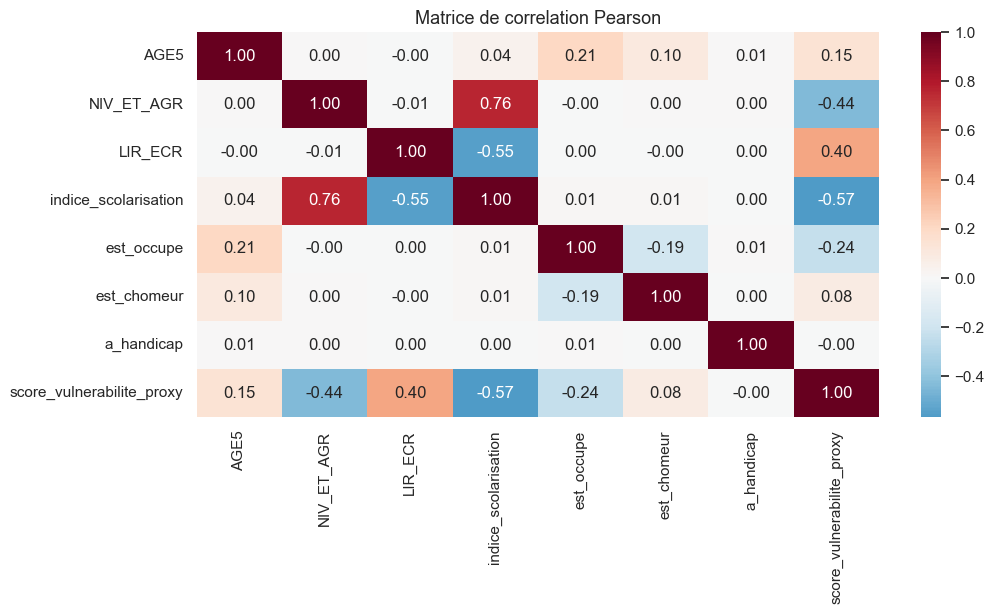

,variable_1,variable_2,correlation
0,NIV_ET_AGR,indice_scolarisation,0.757
1,NIV_ET_AGR,score_vulnerabilite_proxy,-0.439
2,LIR_ECR,indice_scolarisation,-0.552
3,indice_scolarisation,score_vulnerabilite_proxy,-0.566


In [14]:
corr_candidates = [
    COLS.get("age5"),
    COLS.get("educ"),
    COLS.get("alphab"),
    "indice_scolarisation",
    "est_occupe",
    "est_chomeur",
    "a_handicap",
    "score_vulnerabilite_proxy",
]
corr_cols = [c for c in corr_candidates if c and c in df.columns]
corr_df = df[corr_cols].apply(pd.to_numeric, errors="coerce")

pearson_corr = corr_df.corr(method="pearson")
spearman_corr = corr_df.corr(method="spearman")

display(pearson_corr.round(3))

sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Matrice de correlation Pearson")
plt.show()

strong_pairs = []
for i, c1 in enumerate(pearson_corr.columns):
    for c2 in pearson_corr.columns[i+1:]:
        val = pearson_corr.loc[c1, c2]
        if pd.notna(val) and abs(val) >= 0.4:
            strong_pairs.append((c1, c2, val))

if strong_pairs:
    display(pd.DataFrame(strong_pairs, columns=["variable_1", "variable_2", "correlation"]).round(3))
else:
    print("Aucune correlation absolue >= 0.40 detectee parmi les variables selectionnees.")

## 12. PCA - Analyse en composantes principales

La PCA est appliquee sur les indicateurs regionaux. Elle permet de projeter les regions sur deux axes synthetiques pour faciliter l'interpretation visuelle.

,reg,population,score_vulnerabilite_moyen,indice_scolarisation_moyen,taux_emploi,taux_chomage,pct_handicap,age_moyen,pct_mineurs,pct_seniors,pct_alphabete,niv_edu_moyen,ratio_dependance
0,1,8217,4.031,0.521,0.275,0.086,0.471,37.491,18.802,24.960,44.347,2.506,0.438
1,2,8582,4.050,0.517,0.279,0.081,0.465,37.569,18.620,25.216,44.116,2.464,0.438
2,3,8438,4.005,0.524,0.297,0.080,0.474,37.573,18.926,25.219,44.572,2.513,0.441
3,4,8499,4.025,0.518,0.280,0.081,0.479,37.508,18.696,25.191,44.558,2.493,0.439
4,5,8363,3.977,0.520,0.280,0.083,0.469,36.951,19.347,24.465,43.800,2.478,0.438
5,6,8116,4.048,0.516,0.285,0.079,0.459,37.395,19.024,25.025,42.952,2.489,0.440
6,7,8579,4.029,0.517,0.272,0.083,0.470,37.494,19.221,25.446,43.385,2.485,0.447
7,8,8331,4.056,0.518,0.285,0.083,0.469,37.530,18.881,25.159,43.764,2.480,0.440
8,9,8317,4.046,0.520,0.282,0.075,0.461,37.717,18.793,25.358,43.117,2.512,0.442
9,10,8149,4.017,0.521,0.290,0.078,0.465,37.305,19.021,24.788,43.919,2.514,0.438


,reg,PC1,PC2,variance_PC1,variance_PC2
0,1,1.0598,1.1056,0.3577,0.1996
1,2,-1.4609,0.5839,0.3577,0.1996
2,3,1.8023,-0.7868,0.3577,0.1996
3,4,0.4873,0.8105,0.3577,0.1996
4,5,3.5911,1.5771,0.3577,0.1996
5,6,-0.9853,-1.3043,0.3577,0.1996
6,7,-0.1581,-1.6931,0.3577,0.1996
7,8,-0.9026,0.0817,0.3577,0.1996
8,9,-1.2860,-3.1023,0.3577,0.1996
9,10,1.6919,-0.6851,0.3577,0.1996


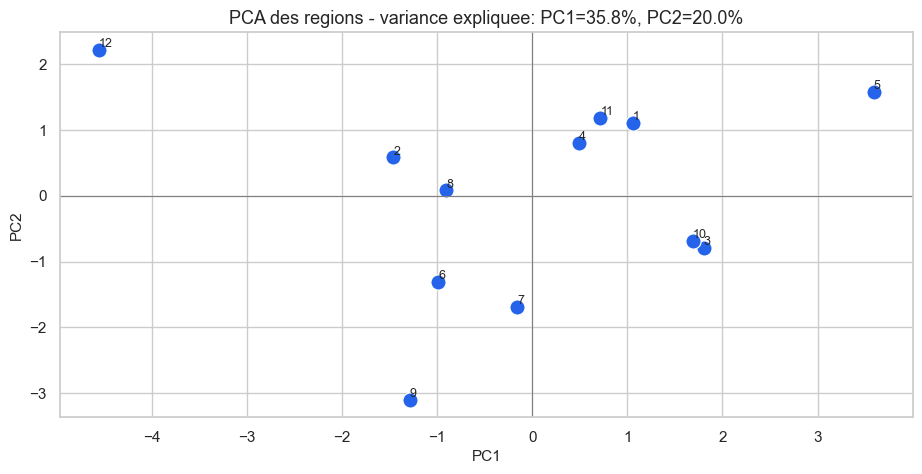

,PC1,PC2
indice_scolarisation_moyen,0.410,-0.207
age_moyen,-0.408,-0.125
pct_mineurs,0.398,-0.244
pct_seniors,-0.377,-0.234
score_vulnerabilite_moyen,-0.373,-0.215
niv_edu_moyen,0.296,-0.393
pct_alphabete,0.294,0.232
pct_handicap,0.206,0.210
taux_emploi,-0.095,0.038
ratio_dependance,0.034,-0.508


In [15]:
def build_regional_table(df: pd.DataFrame) -> pd.DataFrame:
    if region_col is None:
        raise ValueError("La colonne region est indispensable pour l'analyse regionale.")

    agg_spec = {
        "population": (region_col, "count"),
        "score_vulnerabilite_moyen": ("score_vulnerabilite_proxy", "mean"),
        "indice_scolarisation_moyen": ("indice_scolarisation", "mean"),
        "taux_emploi": ("est_occupe", "mean"),
        "taux_chomage": ("est_chomeur", "mean"),
        "pct_handicap": ("a_handicap", "mean"),
    }
    if age_col:
        agg_spec.update({
            "age_moyen": (age_col, "mean"),
            "pct_mineurs": (age_col, lambda s: (pd.to_numeric(s, errors="coerce") < 15).mean() * 100),
            "pct_seniors": (age_col, lambda s: (pd.to_numeric(s, errors="coerce") >= 60).mean() * 100),
        })
    if COLS.get("alphab"):
        agg_spec["pct_alphabete"] = (COLS["alphab"], lambda s: (pd.to_numeric(s, errors="coerce") == 1).mean() * 100)
    if COLS.get("educ"):
        agg_spec["niv_edu_moyen"] = (COLS["educ"], "mean")

    regional = df.groupby(region_col).agg(**agg_spec).reset_index()
    if "pct_mineurs" in regional.columns and "pct_seniors" in regional.columns:
        regional["ratio_dependance"] = ((regional["pct_mineurs"] + regional["pct_seniors"]) / 100).clip(0, 1)
    return regional

stats_regions = build_regional_table(df)
display(stats_regions.round(3))

pca_features = [
    c for c in [
        "age_moyen", "pct_mineurs", "pct_seniors", "pct_alphabete",
        "niv_edu_moyen", "indice_scolarisation_moyen", "taux_emploi",
        "taux_chomage", "pct_handicap", "ratio_dependance",
        "score_vulnerabilite_moyen",
    ] if c in stats_regions.columns
]

X_reg = stats_regions[pca_features].apply(pd.to_numeric, errors="coerce")
X_reg = X_reg.fillna(X_reg.median(numeric_only=True))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reg)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

pca_regions = stats_regions[[region_col]].copy()
pca_regions["PC1"] = coords[:, 0]
pca_regions["PC2"] = coords[:, 1]
pca_regions["variance_PC1"] = pca.explained_variance_ratio_[0]
pca_regions["variance_PC2"] = pca.explained_variance_ratio_[1]
display(pca_regions.round(4))

sns.scatterplot(data=pca_regions, x="PC1", y="PC2", s=120, color="#2563EB")
for _, row in pca_regions.iterrows():
    plt.text(row["PC1"], row["PC2"], str(int(row[region_col])), fontsize=9, ha="left", va="bottom")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title(f"PCA des regions - variance expliquee: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

loadings = pd.DataFrame(pca.components_.T, index=pca_features, columns=["PC1", "PC2"]).sort_values("PC1", key=np.abs, ascending=False)
display(loadings.round(3))

## 13. Segmentation statistique regionale par K-Means

On segmente les regions a partir des indicateurs regionaux. Le nombre de clusters est choisi avec l'elbow method et le silhouette score, puis une projection PCA coloree permet de visualiser les groupes.

,k,inertia,silhouette
0,2,96.2841,0.1660
1,3,77.0551,0.1460
2,4,57.4738,0.1289
3,5,45.3747,0.1077
4,6,32.7514,0.1222
5,7,22.6658,0.1104
6,8,15.0536,0.1287


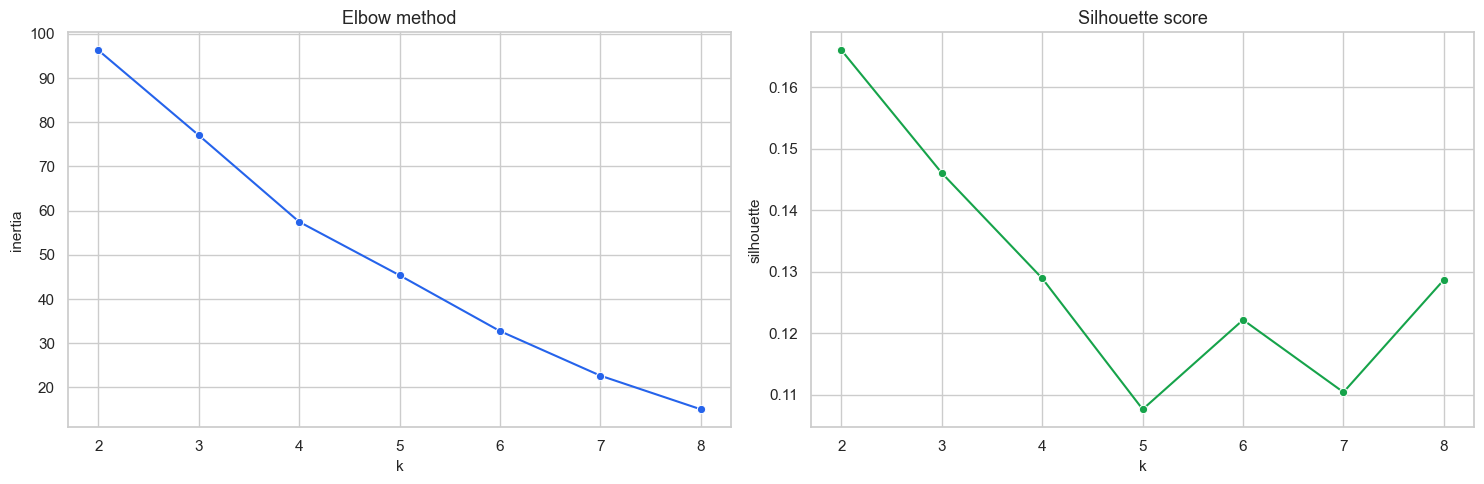

K retenu automatiquement selon silhouette: 2


,age_moyen,pct_mineurs,pct_seniors,pct_alphabete,niv_edu_moyen,indice_scolarisation_moyen,taux_emploi,taux_chomage,pct_handicap,ratio_dependance,score_vulnerabilite_moyen
cluster_statistique,,,,,,,,,,,
0,37.373,18.951,24.897,44.230,2.499,0.520,0.284,0.082,0.471,0.438,4.013
1,37.587,18.778,25.277,43.394,2.479,0.517,0.283,0.081,0.465,0.441,4.044


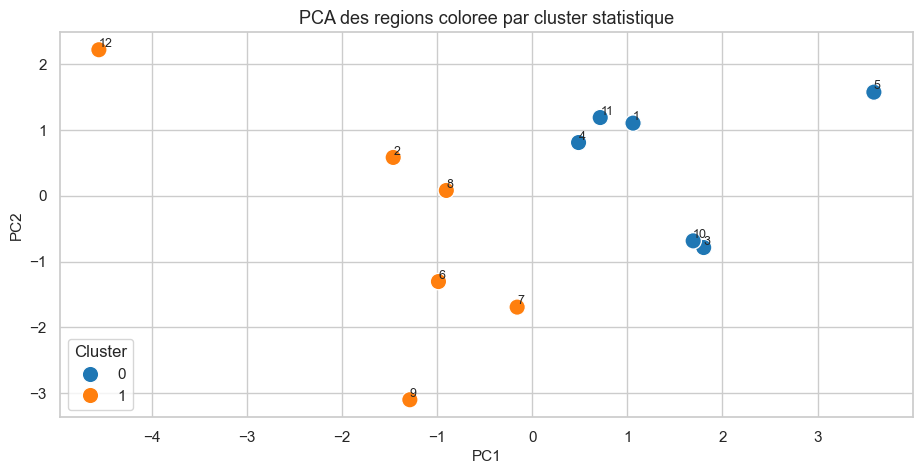

In [16]:
k_values = list(range(2, min(8, len(stats_regions) - 1) + 1))
k_metrics = []

for k in k_values:
    model = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else np.nan
    k_metrics.append({"k": k, "inertia": model.inertia_, "silhouette": sil})

k_metrics_df = pd.DataFrame(k_metrics)
display(k_metrics_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=k_metrics_df, x="k", y="inertia", marker="o", ax=axes[0], color="#2563EB")
axes[0].set_title("Elbow method")
sns.lineplot(data=k_metrics_df, x="k", y="silhouette", marker="o", ax=axes[1], color="#16A34A")
axes[1].set_title("Silhouette score")
plt.tight_layout()
plt.show()

best_k = int(k_metrics_df.sort_values("silhouette", ascending=False).iloc[0]["k"]) if not k_metrics_df.empty else 2
print(f"K retenu automatiquement selon silhouette: {best_k}")

kmeans_final = KMeans(n_clusters=best_k, n_init=50, random_state=RANDOM_STATE)
stats_regions["cluster_statistique"] = kmeans_final.fit_predict(X_scaled)
pca_regions["cluster_statistique"] = stats_regions["cluster_statistique"]

cluster_profile = stats_regions.groupby("cluster_statistique")[pca_features].mean().round(3)
display(cluster_profile)

sns.scatterplot(data=pca_regions, x="PC1", y="PC2", hue="cluster_statistique", palette="tab10", s=140)
for _, row in pca_regions.iterrows():
    plt.text(row["PC1"], row["PC2"], str(int(row[region_col])), fontsize=9, ha="left", va="bottom")
plt.title("PCA des regions coloree par cluster statistique")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

## 14. Export des resultats

Les resultats utiles au rapport, au dashboard et a l'API sont exportes dans `outputs/`.

In [17]:
stats_regions.to_csv(OUTPUT_DIR / "stats_regions.csv", index=False)
pearson_corr.to_csv(OUTPUT_DIR / "correlation_matrix.csv")
pca_regions.to_csv(OUTPUT_DIR / "pca_regions.csv", index=False)
stats_regions.to_csv(OUTPUT_DIR / "clusters_statistiques.csv", index=False)

report_lines = []
report_lines.append("RAPPORT STATISTIQUE AVANCE - RGPH 2014")
report_lines.append("=" * 60)
report_lines.append(f"Nombre d'individus analyses: {len(df):,}")
report_lines.append(f"Nombre de colonnes: {df.shape[1]:,}")
report_lines.append("")
report_lines.append("Colonnes detectees:")
for key, value in COLS.items():
    report_lines.append(f"- {key}: {value}")
report_lines.append("")
report_lines.append("Tests statistiques:")
if "tests_df" in globals() and not tests_df.empty:
    for _, row in tests_df.iterrows():
        report_lines.append(f"- {row['test']}: p-value={row['p_value']:.6g}; {row['interpretation']}")
report_lines.append("")
report_lines.append("Clusters statistiques regionaux:")
report_lines.append(cluster_profile.to_string())

with open(OUTPUT_DIR / "advanced_statistics_report.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print("Exports termines:")
for filename in [
    "stats_regions.csv",
    "correlation_matrix.csv",
    "advanced_statistics_report.txt",
    "pca_regions.csv",
    "clusters_statistiques.csv",
]:
    print("-", OUTPUT_DIR / filename)

Exports termines:
- outputs\stats_regions.csv
- outputs\correlation_matrix.csv
- outputs\advanced_statistics_report.txt
- outputs\pca_regions.csv
- outputs\clusters_statistiques.csv


## 15. Conclusion

Ce notebook fournit une base statistique avancee pour la soutenance du projet RGPH 2014. Les analyses permettent d'identifier les dimensions associees a la vulnerabilite socio-economique : milieu, education, alphabetisme, emploi, handicap et structure d'age.

Les regions les plus vulnerables et les facteurs les plus associes a la vulnerabilite doivent etre lus directement a partir des tableaux calcules ci-dessus, notamment `stats_regions`, `cluster_profile`, la matrice de correlation et les tests statistiques.

Limites principales :

- Le score de vulnerabilite est un proxy academique, construit a partir des variables disponibles.
- Les resultats ne remplacent pas un indicateur officiel du HCP.
- Les tests statistiques indiquent des associations, pas des causalites.
- Les valeurs manquantes conditionnelles doivent etre interpretees avec prudence.

Utilite pour le projet :

- `stats_regions.csv` peut alimenter le dashboard regional.
- `correlation_matrix.csv` documente les relations entre indicateurs.
- `clusters_statistiques.csv` complete la segmentation regionale.
- `advanced_statistics_report.txt` fournit une synthese exploitable dans le rapport SFE.